In [ ]:
# ============================================================
# CELL 1: IMPORTS + CONFIGURATION
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from itertools import cycle
from matplotlib.lines import Line2D


# ============================================================
# Trading parameters
# ============================================================
pstc_lambda = 0.01
trans_cost = 0
bid_ask_spread = 0.0002
borrowing_cost = 0.1

R = 10
a = 10                  # number of assets


# ============================================================
# Hyperparameters
# ============================================================

Epochs = 100
Measures = 5
grids = 4
K = 1
N_trials = 20
epsilon = a


# ============================================================
# Device
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


"RCL_stock_data" "SBUX_stock_data" "UNM_stock_data" "USB_stock_data" "VMC_stock_data" "WELL_stock_data" "WMB_stock_data" "XOM_stock_data" "OKE_stock_data" "PG_stock_data"

In [ ]:
# ============================================================
# CELL 2: UPLOAD STOCK CSV FILES
# ============================================================

from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print(filename)

Saving RCL_stock_data.csv to RCL_stock_data.csv
Saving SBUX_stock_data.csv to SBUX_stock_data.csv
Saving UNM_stock_data.csv to UNM_stock_data.csv
Saving USB_stock_data.csv to USB_stock_data.csv
Saving VMC_stock_data.csv to VMC_stock_data.csv
Saving WELL_stock_data.csv to WELL_stock_data.csv
Saving WMB_stock_data.csv to WMB_stock_data.csv
Saving XOM_stock_data.csv to XOM_stock_data.csv
Saving OKE_stock_data.csv to OKE_stock_data.csv
Saving PG_stock_data.csv to PG_stock_data.csv

Uploaded files:
RCL_stock_data.csv
SBUX_stock_data.csv
UNM_stock_data.csv
USB_stock_data.csv
VMC_stock_data.csv
WELL_stock_data.csv
WMB_stock_data.csv
XOM_stock_data.csv
OKE_stock_data.csv
PG_stock_data.csv


In [ ]:
# ============================================================
# CELL 3: STOCK FILE PATHS
# ============================================================

file_paths = {
    'OKE': "OKE_stock_data.csv",
    'PG': "PG_stock_data.csv",
    'RCL': "RCL_stock_data.csv",
    'SBUX': "SBUX_stock_data.csv",
    'UNM': "UNM_stock_data.csv",
    'USB': "USB_stock_data.csv",
    'VMC': "VMC_stock_data.csv",
    'WELL': "WELL_stock_data.csv",
    'WMB': "WMB_stock_data.csv",
    'XOM': "XOM_stock_data.csv"
}

print(file_paths)

{'OKE': 'OKE_stock_data.csv', 'PG': 'PG_stock_data.csv', 'RCL': 'RCL_stock_data.csv', 'SBUX': 'SBUX_stock_data.csv', 'UNM': 'UNM_stock_data.csv', 'USB': 'USB_stock_data.csv', 'VMC': 'VMC_stock_data.csv', 'WELL': 'WELL_stock_data.csv', 'WMB': 'WMB_stock_data.csv', 'XOM': 'XOM_stock_data.csv'}


In [ ]:
# ============================================================
# CELL 4: LOAD STOCK DATA
# ============================================================

def load_stock_data(file_paths, test_begin_day=4000, test_end_day=5200):

    data_frames = []

    # ---------------- Load CSV files ----------------
    for asset_name, file_path in file_paths.items():

        if os.path.exists(file_path):

            temp = pd.read_csv(
                file_path,
                parse_dates=['Date'],
                dayfirst=True
            )

            temp = temp[['Date', 'Close']]
            temp.columns = ['Date', asset_name]
            temp.dropna(inplace=True)

            data_frames.append(temp)

        else:
            print(f"Warning: {file_path} not found.")

    if not data_frames:
        raise FileNotFoundError(
            "No valid data found in CSV files."
        )

    # ---------------- Merge on Date ----------------
    df = data_frames[0]

    for temp_df in data_frames[1:]:
        df = df.merge(
            temp_df,
            on='Date',
            how='outer'
        )

    df['Date'] = pd.to_datetime(df['Date'])

    df = (
        df
        .sort_values(by='Date')
        .reset_index(drop=True)
    )

    # ---------------- Create asset list ----------------
    asset_list = [
        np.array(df[asset])[:test_end_day]
        for asset in file_paths.keys()
        if asset in df.columns
    ]

    return asset_list, df

In [ ]:
# ============================================================
# CELL 5: UTILITY FUNCTIONS
# ============================================================

def mish(x):
    return x * torch.tanh(F.softplus(x))


def ridgelet_activation(x):
    """
    Ridgelet activation function Ψ(x).

    Here Mish is used as the admissible ridgelet
    nonlinearity.
    """
    return mish(x)


# ============================================================
# Slice functions
# ============================================================

def get_slice_array1(i):

    temp = np.tile(
        np.arange(i + 1),
        a
    )

    return (
        temp
        + np.repeat(
            np.arange(a),
            i + 1
        ) * 8
    )


def get_slice_array2():

    temp = np.tile(
        np.arange(1, 9),
        a
    )

    return (
        temp
        + np.repeat(
            np.arange(a),
            8
        ) * 10
    )


def get_slice_array3():

    temp = np.tile(
        np.arange(1, 10),
        a
    )

    return (
        temp
        + np.repeat(
            np.arange(a),
            9
        ) * 10
    )


def beta(x):

    return torch.pow(
        F.relu(x),
        2
    )

In [ ]:
# ============================================================
# CELL 6: RANDOM PARTITIONS
# ============================================================

def get_random_partition(
    stock_mins,
    stock_maxs,
    num_sets,
    grids=4,
    discrete=True
):

    if grids <= 0:
        raise ValueError("grids must be > 0")

    partition = np.zeros(
        (num_sets, 2 * a)
    )

    stocks_len = (
        stock_maxs - stock_mins
    ) / grids

    for k in range(num_sets):

        if discrete:

            lower = np.random.randint(
                0,
                grids,
                size=a
            )

            gap = np.random.randint(
                1,
                grids - lower + 1,
                size=a
            )

            partition[k, :] = np.repeat(
                stock_mins,
                2
            )

            partition[k, ::2] += (
                lower * stocks_len
            )

            partition[k, 1::2] += (
                (lower + gap) * stocks_len
            )

        else:

            lower = np.random.uniform(
                low=stock_mins,
                high=stock_maxs
            )

            upper = stock_maxs

            partition[k, ::2] = lower
            partition[k, 1::2] = upper

    return partition


# ============================================================
# Indicator matrix
# ============================================================

def get_indicator_matrix(
    partition,
    S_n
):

    B = partition.shape[0]

    indicator_matrix = np.zeros(
        (len(S_n), 2 ** B)
    )

    for i in range(len(S_n)):

        temp = np.ones(
            B,
            dtype=bool
        )

        for j in range(a):

            temp = temp & (
                partition[:, 2*j] < S_n[i, j]
            )

        temp = temp.flatten().astype(int)

        pos = int(
            np.array2string(
                temp,
                formatter={
                    'int': lambda x: bin(x)
                }
            )[1:-1]
            .replace(' ', '')[2::3],
            2
        )

        indicator_matrix[i][pos] = 1

    return torch.FloatTensor(
        indicator_matrix
    )

In [ ]:
# ============================================================
# CELL 7: FRACTION VECTOR / LOSS COMPONENT
# ============================================================

def get_frac_vector(
    P_tau_tilde,
    indicator_matrix,
    net,
    P_original
):

    # --------------------------------------------------------
    # Model input
    # --------------------------------------------------------

    net_input = P_tau_tilde[
        :,
        get_slice_array2()
    ]

    delta_list, c = net(net_input)


    # --------------------------------------------------------
    # Initialize transaction cost and P&L
    # --------------------------------------------------------

    h_value_trans = 0
    h_value_pnl = 0


    # ========================================================
    # Asset loop
    # ========================================================

    for i in range(a):

        delta = delta_list[i]

        # ----------------------------------------------------
        # Construct trades
        # ----------------------------------------------------
        #
        # delta contains 9 positions:
        #
        # [δ1, δ2, ..., δ9]
        #
        # Trades:
        #
        # [ |δ1|,
        #   |δ2-δ1|,
        #   ...
        #   |δ9-δ8|,
        #   |δ9| ]
        #
        # The first value represents entering the position.
        # The last value represents closing the position.
        #
        # Therefore there are 10 trade values.
        # ----------------------------------------------------

        trades = torch.abs(
            torch.cat(
                (
                    delta[:, :1],
                    delta[:, 1:] - delta[:, :-1],
                    delta[:, -1:]
                ),
                dim=1
            )
        )


        # ----------------------------------------------------
        # PRICE-SENSITIVE TRANSACTION COST (PSTC)
        # ----------------------------------------------------
        #
        # PSTC:
        #
        # λ_T * S_t * |Trade_t|
        #
        # where:
        #
        # λ_T = pstc_lambda = 0.01
        #
        # IMPORTANT:
        # P_original contains the ORIGINAL stock prices.
        #
        # P_tau_tilde is normalized and therefore must NOT
        # be used here for the price-sensitive cost.
        # ----------------------------------------------------

        prices = P_original[
            :,
            10*i : 10*i + 10
        ]


        h_value_trans += (
            pstc_lambda
            * prices
            * trades
        ).sum(axis=1)


        # ----------------------------------------------------
        # P&L
        # ----------------------------------------------------

        h_value_pnl += (
            (
                P_tau_tilde[
                    :,
                    10*i + 1 : 10*i + 10
                ]
                -
                P_tau_tilde[
                    :,
                    10*i : 10*i + 9
                ]
            )
            * delta
        ).sum(axis=1)


    # --------------------------------------------------------
    # Final h-value
    # --------------------------------------------------------

    h_value = (
        -c
        + h_value_trans
        - h_value_pnl
    )


    # --------------------------------------------------------
    # Aggregate according to indicator matrix
    # --------------------------------------------------------

    temp = torch.matmul(
        indicator_matrix.T,
        h_value
    )


    indicator_sum = torch.sum(
        indicator_matrix.T,
        dim=1
    )


    indicator_sum = torch.where(
        indicator_sum.abs() > 0.5,
        indicator_sum,
        torch.ones(
            (),
            device=indicator_sum.device,
            dtype=indicator_sum.dtype
        )
    )


    return temp / indicator_sum

In [ ]:
# ============================================================
# CELL 8: HRDNN MODEL
# ============================================================

class HRDNN(nn.Module):

    def __init__(self, R, a):

        super(HRDNN, self).__init__()

        self.first_layers = nn.ModuleList([
            nn.Linear(a * i, 32 * a)
            for i in range(1, 9)
        ])

        self.bn_layers = nn.ModuleList([
            nn.BatchNorm1d(a * i)
            for i in range(1, 9)
        ])

        self.second_layers = nn.ModuleList([
            nn.Linear(32 * a, 64 * a)
            for i in range(1, 9)
        ])

        self.third_layers = nn.ModuleList([
            nn.Linear(64 * a, 128 * a)
            for i in range(1, 9)
        ])

        self.fourth_layers = nn.ModuleList([
            nn.Linear(128 * a, a)
            for i in range(1, 9)
        ])

        self.c = nn.Parameter(
            torch.FloatTensor([0])
        )

        self.delta0_s = nn.Parameter(
            torch.FloatTensor([0] * a)
        )

        self.R = R
        self.a = a


    def forward(self, x):

        # ----------------------------------------------------
        # Feature extraction
        # ----------------------------------------------------

        output1 = [
            F.relu(
                self.first_layers[i](
                    self.bn_layers[i](
                        x[:, get_slice_array1(i)]
                    )
                )
            )
            for i in range(8)
        ]


        # ----------------------------------------------------
        # Second layer
        # ----------------------------------------------------

        output2 = [
            F.relu(
                self.second_layers[i](
                    output1[i]
                )
            )
            for i in range(8)
        ]


        # ----------------------------------------------------
        # Ridgelet layer
        # ----------------------------------------------------

        output3 = [
            ridgelet_activation(
                self.third_layers[i](
                    output2[i]
                )
            )
            for i in range(8)
        ]


        # ----------------------------------------------------
        # Trading positions
        # ----------------------------------------------------

        deltas = [
            self.R
            * torch.tanh(
                self.fourth_layers[i](
                    output3[i]
                )
            )
            for i in range(8)
        ]


        # ----------------------------------------------------
        # Construct delta list for every asset
        # ----------------------------------------------------

        delta_list = [
            torch.cat(
                [
                    delta[:, i:i+1]
                    for delta in deltas
                ],
                axis=1
            )
            for i in range(self.a)
        ]


        # ----------------------------------------------------
        # Add initial position
        # ----------------------------------------------------

        return [
            torch.cat(
                (
                    self.delta0_s[i]
                    * torch.ones(
                        (x.shape[0], 1)
                    ).to(device),

                    delta_list[i]
                ),
                axis=1
            )
            for i in range(self.a)
        ], self.c

In [ ]:
# ============================================================
# CELL 9: HRDNN STATISTICAL ARBITRAGE EVALUATION
# ============================================================

def stat_arb_success(stock_test, net):

    f = 0

    gain_list = []
    cost_list = []
    success = []

    gross_exposure_list = []
    net_exposure_list = []
    turnover_list = []

    prev_delta = {
        k: np.zeros(9)
        for k in range(a)
    }


    # ========================================================
    # 10-day windows
    # ========================================================

    for i in range(
        int(len(stock_test[0]) / 10)
    ):

        query_data = np.zeros(
            (1, 8 * a)
        )


        # ----------------------------------------------------
        # Construct model input
        # ----------------------------------------------------

        for j in range(a):

            query_data[
                0,
                8*j : 8*(j+1)
            ] = (
                100
                * stock_test[j][
                    10*i+1 : 10*i+9
                ]
                /
                stock_test[j][10*i]
            ).reshape(1, -1)


        # ----------------------------------------------------
        # Model prediction
        # ----------------------------------------------------

        upper_bound = net(
            torch.FloatTensor(
                query_data
            ).to(device)
        )[0]


        upper_bound_list = [
            delta.detach()
            .cpu()
            .numpy()[0]
            for delta in upper_bound
        ]


        gain = 0
        cost = 0


        # ====================================================
        # P&L calculation
        # ====================================================

        for k in range(a):

            delta = upper_bound_list[k]


            # ------------------------------------------------
            # Exposure statistics
            # ------------------------------------------------

            gross_exposure_list.append(
                np.abs(delta).sum()
            )

            net_exposure_list.append(
                delta.sum()
            )


            turnover_list.append(
                np.abs(
                    delta - prev_delta[k]
                ).sum()
            )


            prev_delta[k] = delta.copy()


            # ------------------------------------------------
            # Trading gain
            # ------------------------------------------------

            gain += np.dot(
                delta,
                stock_test[k][
                    10*i+1 : 10*i+10
                ]
                -
                stock_test[k][
                    10*i : 10*i+9
                ]
            )


            # ------------------------------------------------
            # Construct trades
            # ------------------------------------------------

            trades = np.abs(
                np.concatenate(
                    [
                        np.array([delta[0]]),
                        delta[1:] - delta[:-1],
                        np.array([delta[-1]])
                    ]
                )
            )


            # ------------------------------------------------
            # PTC
            # ------------------------------------------------

            cost += (
                trans_cost
                * trades
            ).sum()


            # ------------------------------------------------
            # PSTC
            # ------------------------------------------------
            #
            # Cost = lambda_T * S_t * |Trade_t|
            #
            # Use ORIGINAL stock prices.
            # ------------------------------------------------

            cost += (
                pstc_lambda
                * stock_test[k][
                    10*i : 10*i+10
                ]
                * trades
            ).sum()


            # ------------------------------------------------
            # Bid-ask spread
            # ------------------------------------------------

            cost += (
                0.5
                * bid_ask_spread
                * trades
            ).sum()


            # ------------------------------------------------
            # Borrowing cost
            # ------------------------------------------------

            cost += (
                borrowing_cost / 252.0
                * np.maximum(-delta, 0)
                * stock_test[k][
                    10*i : 10*i+9
                ]
            ).sum()


        # ----------------------------------------------------
        # Net success
        # ----------------------------------------------------

        success.append(
            gain - cost
        )

        gain_list.append(gain)
        cost_list.append(cost)

        f += success[-1]


    # ========================================================
    # Basic statistics
    # ========================================================

    print(
        "Average Gross Gain:",
        np.array(gain_list).mean(),
        "Average Total Cost:",
        np.array(cost_list).mean()
    )


    success = np.array(success)

    res = {}

    res['Gain'] = f

    res['Best'] = round(
        max(success),
        2
    )

    res['Worst'] = round(
        min(success),
        2
    )

    res['Average'] = round(
        success.mean(),
        2
    )

    res['Std'] = round(
        success.std(),
        2
    )


    # --------------------------------------------------------
    # Percentage of profitable windows
    # --------------------------------------------------------

    res['loss_perc'] = round(
        100 * float(
            np.sum(success < 0)
            /
            len(success)
        ),
        2
    )


    res['gains_perc'] = round(
        100 * float(
            np.sum(success > 0)
            /
            len(success)
        ),
        2
    )


    # --------------------------------------------------------
    # Sharpe ratio
    # --------------------------------------------------------

    res['sharp_ratio'] = round(
        np.sqrt(252.0 / 9)
        * success.mean()
        / success.std(),
        3
    )


    # --------------------------------------------------------
    # Sortino ratio
    # --------------------------------------------------------

    res['sortino_ratio'] = round(
        np.sqrt(252.0 / 9)
        * success.mean()
        /
        success[success < 0].std(),
        3
    )


    # --------------------------------------------------------
    # Turnover
    # --------------------------------------------------------

    res['Turnover'] = round(
        np.mean(turnover_list),
        4
    )


    # --------------------------------------------------------
    # Gross exposure
    # --------------------------------------------------------

    res['Gross_Exposure'] = round(
        np.mean(gross_exposure_list),
        4
    )


    # --------------------------------------------------------
    # Net exposure
    # --------------------------------------------------------

    res['Net_Exposure'] = round(
        np.mean(net_exposure_list),
        4
    )


    # ========================================================
    # CVaR
    # ========================================================

    var_90 = np.percentile(
        success,
        10
    )

    var_95 = np.percentile(
        success,
        5
    )

    var_99 = np.percentile(
        success,
        1
    )


    res['CVaR_90'] = round(
        success[
            success <= var_90
        ].mean(),
        3
    )

    res['CVaR_95'] = round(
        success[
            success <= var_95
        ].mean(),
        3
    )

    res['CVaR_99'] = round(
        success[
            success <= var_99
        ].mean(),
        3
    )


    return res

In [ ]:
# ============================================================
# CELL 10: BUY & HOLD BENCHMARK
# ============================================================

def stat_arb_success_buy_and_hold(stock_test):

    f = 0

    gain_list = []
    cost_list = []
    success = []


    for i in range(
        int(len(stock_test[0]) / 10)
    ):

        gain = 0
        cost = 0


        for k in range(a):

            # ------------------------------------------------
            # Buy and Hold:
            # 10 shares throughout the 9 periods
            # ------------------------------------------------

            delta = 10 * np.ones(9)


            # ------------------------------------------------
            # Gross P&L
            # ------------------------------------------------

            gain += np.dot(
                delta,
                stock_test[k][
                    10*i+1 : 10*i+10
                ]
                -
                stock_test[k][
                    10*i : 10*i+9
                ]
            )


            # ------------------------------------------------
            # Trades
            # ------------------------------------------------

            trades = np.abs(
                np.concatenate(
                    [
                        np.array([delta[0]]),
                        delta[1:] - delta[:-1],
                        np.array([delta[-1]])
                    ]
                )
            )


            # ------------------------------------------------
            # PTC
            # ------------------------------------------------

            cost += (
                trans_cost
                * trades
            ).sum()


            # ------------------------------------------------
            # PSTC
            # ------------------------------------------------

            cost += (
                pstc_lambda
                * stock_test[k][
                    10*i : 10*i+10
                ]
                * trades
            ).sum()


            # ------------------------------------------------
            # Bid-ask spread
            # ------------------------------------------------

            cost += (
                0.5
                * bid_ask_spread
                * trades
            ).sum()


            # ------------------------------------------------
            # Borrowing cost
            # ------------------------------------------------

            cost += (
                borrowing_cost / 252.0
                * np.maximum(-delta, 0)
                * stock_test[k][
                    10*i : 10*i+9
                ]
            ).sum()


        success.append(
            gain - cost
        )

        gain_list.append(gain)
        cost_list.append(cost)

        f += success[-1]


    print(
        "Average Gross Gain:",
        np.array(gain_list).mean(),
        "Average Total Cost:",
        np.array(cost_list).mean()
    )


    success = np.array(success)

    res = {}

    res['Gain'] = f

    res['Best'] = round(
        max(success),
        2
    )

    res['Worst'] = round(
        min(success),
        2
    )

    res['Average'] = round(
        success.mean(),
        2
    )

    res['Std'] = round(
        success.std(),
        2
    )


    res['loss_perc'] = round(
        100 * float(
            np.sum(success < 0)
            /
            len(success)
        ),
        2
    )

    res['gains_perc'] = round(
        100 * float(
            np.sum(success > 0)
            /
            len(success)
        ),
        2
    )


    res['sharp_ratio'] = round(
        np.sqrt(252.0 / 9)
        * success.mean()
        / success.std(),
        3
    )


    res['sortino_ratio'] = round(
        np.sqrt(252.0 / 9)
        * success.mean()
        /
        success[success < 0].std(),
        3
    )


    # --------------------------------------------------------
    # CVaR
    # --------------------------------------------------------

    var_90 = np.percentile(
        success,
        10
    )

    var_95 = np.percentile(
        success,
        5
    )

    var_99 = np.percentile(
        success,
        1
    )


    res['CVaR_90'] = round(
        success[
            success <= var_90
        ].mean(),
        3
    )

    res['CVaR_95'] = round(
        success[
            success <= var_95
        ].mean(),
        3
    )

    res['CVaR_99'] = round(
        success[
            success <= var_99
        ].mean(),
        3
    )


    return res

In [ ]:
# ============================================================
# CELL 11: BUY & HOLD ONCE
# ============================================================

def stat_arb_success_buy_and_hold_only_once(stock_test):

    pnl = 0

    for k in range(a):

        # ----------------------------------------------------
        # Gross Buy & Hold P&L
        # ----------------------------------------------------

        pnl += (
            10
            * (
                stock_test[k][-1]
                -
                stock_test[k][0]
            )
        )


        # ----------------------------------------------------
        # Entry + exit trades
        # ----------------------------------------------------

        entry_trade = 10
        exit_trade = 10


        # ----------------------------------------------------
        # PTC
        # ----------------------------------------------------

        pnl -= (
            trans_cost
            * (
                entry_trade
                +
                exit_trade
            )
        )


        # ----------------------------------------------------
        # PSTC
        #
        # Entry occurs at first price.
        # Exit occurs at final price.
        # ----------------------------------------------------

        pnl -= (
            pstc_lambda
            * stock_test[k][0]
            * entry_trade
        )

        pnl -= (
            pstc_lambda
            * stock_test[k][-1]
            * exit_trade
        )


        # ----------------------------------------------------
        # Bid-ask spread
        # ----------------------------------------------------

        pnl -= (
            0.5
            * bid_ask_spread
            * (
                entry_trade
                +
                exit_trade
            )
        )


    print(
        "Buy and Hold profit:",
        pnl
        /
        int(len(stock_test[0]) / 10)
    )

In [ ]:
# ============================================================
# CELL 12: 1/N BENCHMARK
# ============================================================

def stat_arb_success_1overN(stock_test):

    f = 0

    gain_list = []
    cost_list = []
    success = []


    # --------------------------------------------------------
    # Equal-weight position
    # --------------------------------------------------------

    delta_fixed = (
        R / a
    ) * np.ones(9)


    # ========================================================
    # 10-day windows
    # ========================================================

    for i in range(
        int(len(stock_test[0]) / 10)
    ):

        gain = 0
        cost = 0


        for k in range(a):

            delta = delta_fixed


            # ------------------------------------------------
            # Gross P&L
            # ------------------------------------------------

            gain += np.dot(
                delta,
                stock_test[k][
                    10*i+1 : 10*i+10
                ]
                -
                stock_test[k][
                    10*i : 10*i+9
                ]
            )


            # ------------------------------------------------
            # Trades
            # ------------------------------------------------

            trades = np.abs(
                np.concatenate(
                    [
                        np.array([delta[0]]),
                        delta[1:] - delta[:-1],
                        np.array([delta[-1]])
                    ]
                )
            )


            # ------------------------------------------------
            # PTC
            # ------------------------------------------------

            cost += (
                trans_cost
                * trades
            ).sum()


            # ------------------------------------------------
            # PSTC
            # ------------------------------------------------

            cost += (
                pstc_lambda
                * stock_test[k][
                    10*i : 10*i+10
                ]
                * trades
            ).sum()


            # ------------------------------------------------
            # Bid-ask spread
            # ------------------------------------------------

            cost += (
                0.5
                * bid_ask_spread
                * trades
            ).sum()


            # ------------------------------------------------
            # Borrowing cost
            # ------------------------------------------------

            cost += (
                borrowing_cost / 252.0
                * np.maximum(-delta, 0)
                * stock_test[k][
                    10*i : 10*i+9
                ]
            ).sum()


        # ----------------------------------------------------
        # Net result
        # ----------------------------------------------------

        success.append(
            gain - cost
        )

        gain_list.append(gain)
        cost_list.append(cost)

        f += success[-1]


    # ========================================================
    # Statistics
    # ========================================================

    success = np.array(success)

    res = {}

    res['Gain'] = f

    res['Best'] = round(
        max(success),
        2
    )

    res['Worst'] = round(
        min(success),
        2
    )

    res['Average'] = round(
        success.mean(),
        2
    )

    res['Std'] = round(
        success.std(),
        2
    )


    res['loss_perc'] = round(
        100 * float(
            np.sum(success < 0)
            /
            len(success)
        ),
        2
    )

    res['gains_perc'] = round(
        100 * float(
            np.sum(success > 0)
            /
            len(success)
        ),
        2
    )


    res['sharp_ratio'] = round(
        np.sqrt(252.0 / 9)
        * success.mean()
        / success.std(),
        3
    )


    res['sortino_ratio'] = round(
        np.sqrt(252.0 / 9)
        * success.mean()
        /
        success[success < 0].std(),
        3
    )


    # ========================================================
    # CVaR
    # ========================================================

    var_90 = np.percentile(
        success,
        10
    )

    var_95 = np.percentile(
        success,
        5
    )

    var_99 = np.percentile(
        success,
        1
    )


    res['CVaR_90'] = round(
        success[
            success <= var_90
        ].mean(),
        3
    )

    res['CVaR_95'] = round(
        success[
            success <= var_95
        ].mean(),
        3
    )

    res['CVaR_99'] = round(
        success[
            success <= var_99
        ].mean(),
        3
    )


    return res

In [ ]:
# ============================================================
# CELL 13: LOAD + TRAIN/TEST SPLIT
# ============================================================

test_begin_day = 4000
test_end_day = 5200

asset_list, df = load_stock_data(
    file_paths,
    test_begin_day,
    test_end_day
)

stock_train = [
    asset[:test_begin_day]
    for asset in asset_list
]

stock_test = [
    asset[test_begin_day:test_end_day]
    for asset in asset_list
]


print("Number of assets:", len(asset_list))

print(
    "Training length:",
    len(stock_train[0])
)

print(
    "Testing length:",
    len(stock_test[0])
)

print(
    "DataFrame shape:",
    df.shape
)

Number of assets: 10
Training length: 4000
Testing length: 1200
DataFrame shape: (5284, 11)


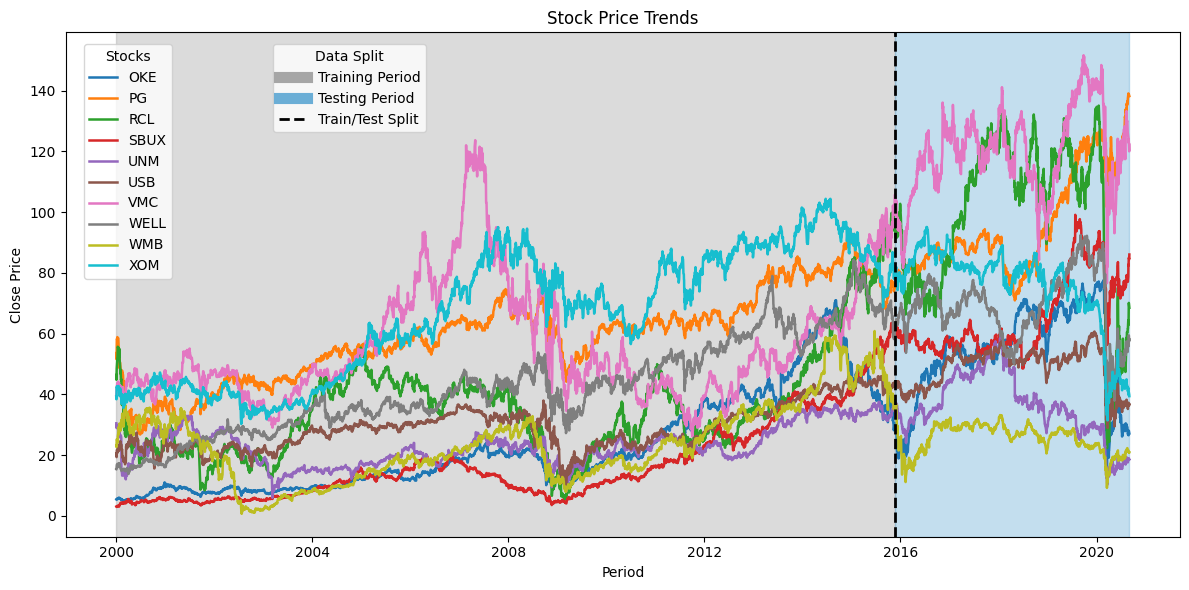

In [ ]:
# ============================================================
# CELL 14: TRAIN / TEST PRICE PLOT
# ============================================================

train_start = 0
train_end = test_begin_day

test_start = test_begin_day
test_end = test_end_day

split_date = df['Date'][train_end - 1]


plt.figure(figsize=(12, 6))


# Training background
plt.axvspan(
    df['Date'].iloc[train_start],
    split_date,
    color='#a6a6a6',
    alpha=0.40
)


# Testing background
plt.axvspan(
    split_date,
    df['Date'].iloc[test_end - 1],
    color='#6baed6',
    alpha=0.40
)


colors = cycle(
    plt.cm.tab10.colors
)


for asset_name, color in zip(
    file_paths.keys(),
    colors
):

    if asset_name in df.columns:

        plt.plot(
            df['Date'][
                train_start:train_end
            ],
            df[asset_name][
                train_start:train_end
            ],
            linewidth=1.8,
            color=color,
            label=asset_name
        )


        plt.plot(
            df['Date'][
                test_start:test_end
            ],
            df[asset_name][
                test_start:test_end
            ],
            linewidth=1.8,
            color=color
        )


plt.axvline(
    x=split_date,
    color='black',
    linestyle='--',
    linewidth=2
)


plt.xlabel("Period")
plt.ylabel("Close Price")
plt.title("Stock Price Trends")


stock_legend = plt.legend(
    title="Stocks",
    loc='upper left',
    frameon=True,
    bbox_to_anchor=(0.01, 0.99)
)

plt.gca().add_artist(stock_legend)


phase_legend = [
    Line2D(
        [0], [0],
        color='#a6a6a6',
        lw=8,
        label='Training Period'
    ),

    Line2D(
        [0], [0],
        color='#6baed6',
        lw=8,
        label='Testing Period'
    ),

    Line2D(
        [0], [0],
        color='black',
        lw=2,
        linestyle='--',
        label='Train/Test Split'
    )
]


plt.legend(
    handles=phase_legend,
    title="Data Split",
    loc='upper left',
    frameon=True,
    bbox_to_anchor=(0.18, 0.99)
)


plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# CELL 15: CONSTRUCT P_hat
# ============================================================

N = len(stock_train[0])

n = 10 - 1

P_hat = np.zeros(
    (
        a * (n + 1),
        N - n
    )
)


for j in range(a):

    for i in range(n + 1):

        P_hat[
            i + j * (n + 1),
            :
        ] = stock_train[j][
            i : N - n + i
        ]


P_hat = torch.FloatTensor(
    P_hat.T
)


print("P_hat shape:", P_hat.shape)

P_hat shape: torch.Size([3991, 100])


In [ ]:
# ============================================================
# CELL 16: CALCULATE STATE BOUNDS
# ============================================================

S_lower = torch.FloatTensor(
    [100] * a
)

S_upper = torch.FloatTensor(
    [-100] * a
)


for i in range(a):

    for j in range(1, n + 1):

        S_lower[i] = torch.min(
            S_lower[i],
            torch.min(
                P_hat[
                    :,
                    10*i+j
                ]
                /
                P_hat[
                    :,
                    10*i
                ]
            )
        )


        S_upper[i] = torch.max(
            S_upper[i],
            torch.max(
                P_hat[
                    :,
                    10*i+j
                ]
                /
                P_hat[
                    :,
                    10*i
                ]
            )
        )


rescaled_lower_bounds = (
    S_lower * 100 - a
)

rescaled_upper_bounds = (
    S_upper * 100 + a
)


print("Lower bounds:")
print(rescaled_lower_bounds)

print("\nUpper bounds:")
print(rescaled_upper_bounds)

Lower bounds:
tensor([57.3547, 50.7774, 26.4745, 57.9621, 35.9231, 48.6300, 59.8467, 66.0733,
         3.9241, 66.0553])

Upper bounds:
tensor([144.8727, 132.4669, 159.7041, 150.1451, 170.2003, 189.4785, 174.5710,
        135.6705, 481.5909, 131.4404])


In [ ]:
# ============================================================
# CELL 17: BENCHMARKS
# ============================================================

print("\n================ BENCHMARKS ================\n")


# ------------------------------------------------------------
# Buy & Hold
# ------------------------------------------------------------

bh_result = stat_arb_success_buy_and_hold(
    stock_test
)

print(
    "Buy and Hold:",
    bh_result
)


# ------------------------------------------------------------
# Buy & Hold — once
# ------------------------------------------------------------

stat_arb_success_buy_and_hold_only_once(
    stock_test
)


# ------------------------------------------------------------
# 1/N
# ------------------------------------------------------------

one_over_n_result = stat_arb_success_1overN(
    stock_test
)

print(
    "1/N Benchmark:",
    one_over_n_result
)


================ BENCHMARKS ================

Average Gross Gain: -2.3441639741262064 Average Total Cost: 137.8227415394783
Buy and Hold: {'Gain': np.float64(-16820.028661632543), 'Best': np.float64(886.34), 'Worst': np.float64(-2141.77), 'Average': np.float64(-140.17), 'Std': np.float64(293.2), 'loss_perc': 78.33, 'gains_perc': 21.67, 'sharp_ratio': np.float64(-2.53), 'sortino_ratio': np.float64(-2.683), 'CVaR_90': np.float64(-701.469), 'CVaR_95': np.float64(-988.157), 'CVaR_99': np.float64(-1817.806)}
Buy and Hold profit: -1.805983350435889
1/N Benchmark: {'Gain': np.float64(-1682.0028661632548), 'Best': np.float64(88.63), 'Worst': np.float64(-214.18), 'Average': np.float64(-14.02), 'Std': np.float64(29.32), 'loss_perc': 78.33, 'gains_perc': 21.67, 'sharp_ratio': np.float64(-2.53), 'sortino_ratio': np.float64(-2.683), 'CVaR_90': np.float64(-70.147), 'CVaR_95': np.float64(-98.816), 'CVaR_99': np.float64(-181.781)}


In [ ]:
# ============================================================
# CELL 18: HRDNN TRAINING
# ============================================================

pnl = []

trained_models = []


for trial in range(N_trials):

    print("\n")
    print("=" * 70)
    print("TRIAL:", trial + 1, "/", N_trials)
    print("=" * 70)


    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    np.random.seed(trial)
    torch.manual_seed(trial)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(trial)


    # --------------------------------------------------------
    # Create network
    # --------------------------------------------------------

    net = HRDNN(
        R,
        a
    ).to(device)

    net.train()


    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = optim.Adam(
        net.parameters(),
        lr=1e-4
    )


    loss_rec = []
    c_rec = []


    # ========================================================
    # EPOCH LOOP
    # ========================================================

    for epoch in range(Epochs):


        # ----------------------------------------------------
        # Evaluate every 10 epochs
        # ----------------------------------------------------

        if epoch % 10 == 0:

            net.eval()

            print(
                "\nTest at Epoch",
                epoch
            )

            result = stat_arb_success(
                stock_test,
                net
            )

            print(result)

            net.train()


        # ----------------------------------------------------
        # Reset gradients
        # ----------------------------------------------------

        optimizer.zero_grad()

        total_loss = 0


        # ----------------------------------------------------
        # Generate random partition
        # ----------------------------------------------------

        partition = get_random_partition(
            rescaled_lower_bounds,
            rescaled_upper_bounds,
            num_sets=12,
            discrete=False
        )


        # ====================================================
        # Monte Carlo / Measure loop
        # ====================================================

        for m in range(Measures):


            batch_index = np.arange(
                P_hat.shape[0]
            )


            # --------------------------------------------------------
            # Copy ORIGINAL P_hat
            # --------------------------------------------------------

            P_tau_tilde = P_hat.clone()

            # Keep an untouched copy of the actual stock prices.
            #
            # This is required for PSTC because:
            #
            # PSTC = lambda * actual_stock_price * |trade|
            #
            P_original = P_tau_tilde.clone()


            # --------------------------------------------------------
            # Normalize each asset's prices
            # --------------------------------------------------------

            for j in range(a):

                P_tau_tilde[
                    :,
                    10*j : 10*(j+1)
                ] /= (
                    (
                        P_tau_tilde[
                            :,
                            10*j
                        ] / 100
                    ).reshape(-1, 1)
                )


            # --------------------------------------------------------
            # Generate perturbation
            # --------------------------------------------------------

            tau_m = torch.FloatTensor(
                np.random.normal(
                    0,
                    1,
                    (
                        P_hat.shape[0],
                        P_hat.shape[1] - a
                    )
                )
            )


            # --------------------------------------------------------
            # Random epsilon
            # --------------------------------------------------------

            U_epsilon = torch.FloatTensor(
                epsilon
                * np.random.rand(1)
            )


            # --------------------------------------------------------
            # Normalize perturbation
            # --------------------------------------------------------

            tau_tilde = (
                U_epsilon
                * tau_m
                /
                torch.norm(
                    tau_m,
                    p=2,
                    dim=1,
                    keepdim=True
                )
            )


            # --------------------------------------------------------
            # Add perturbation
            # --------------------------------------------------------

            P_tau_tilde[
                :,
                get_slice_array3()
            ] += tau_tilde


            # --------------------------------------------------------
            # State S_n
            # --------------------------------------------------------

            S_n = P_tau_tilde[
                :,
                np.arange(1, a + 1) * 10 - 1
            ].numpy()


            S_n = S_n[
                batch_index
            ]


            # --------------------------------------------------------
            # Indicator matrix
            # --------------------------------------------------------

            indicator_matrix = get_indicator_matrix(
                partition,
                S_n
            ).to(device)


            # --------------------------------------------------------
            # Move data to device
            # --------------------------------------------------------

            P_tau_tilde = P_tau_tilde.to(device)

            P_tau_tilde = P_tau_tilde[
                batch_index
            ]


            # --------------------------------------------------------
            # Move ORIGINAL prices to device
            # --------------------------------------------------------

            P_original = P_original.to(device)

            P_original = P_original[
                batch_index
            ]


            # --------------------------------------------------------
            # Fraction vector
            # --------------------------------------------------------

            frac_vector = get_frac_vector(
                P_tau_tilde,
                indicator_matrix,
                net,
                P_original
            )


            # --------------------------------------------------------
            # Loss
            # --------------------------------------------------------

            total_loss += (
                beta(
                    torch.matmul(
                        indicator_matrix,
                        frac_vector
                    )
                ).sum()
                /
                len(S_n)
            )


        # ----------------------------------------------------
        # Add c
        # ----------------------------------------------------

        total_loss = (
            net.c
            +
            K * total_loss
        )


        # ----------------------------------------------------
        # Record loss
        # ----------------------------------------------------

        loss_rec.append(
            total_loss.item()
        )

        c_rec.append(
            net.c
            .clone()
            .detach()
            .cpu()
            .numpy()[0]
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        total_loss.backward()

        optimizer.step()


        # ----------------------------------------------------
        # Clamp parameters
        # ----------------------------------------------------

        with torch.no_grad():

            net.c.clamp_(
                -R,
                R
            )

            net.delta0_s.clamp_(
                -R,
                R
            )


    # ========================================================
    # END OF TRIAL
    # ========================================================

    net.eval()


    record = stat_arb_success(
        stock_test,
        net
    )


    pnl.append(record)

    trained_models.append(net)


    print(
        "\nTrial",
        trial + 1,
        "final result:"
    )

    print(record)



TRIAL: 1 / 20

Test at Epoch 0
Average Gross Gain: -1.1425523948659944 Average Total Cost: 570.4579029659924
{'Gain': np.float64(-68592.05464330297), 'Best': np.float64(-200.24), 'Worst': np.float64(-869.11), 'Average': np.float64(-571.6), 'Std': np.float64(126.29), 'loss_perc': 100.0, 'gains_perc': 0.0, 'sharp_ratio': np.float64(-23.949), 'sortino_ratio': np.float64(-23.949), 'Turnover': np.float64(2.4273), 'Gross_Exposure': np.float32(67.3026), 'Net_Exposure': np.float32(1.3084), 'CVaR_90': np.float64(-780.359), 'CVaR_95': np.float64(-824.771), 'CVaR_99': np.float64(-863.041)}


/tmp/ipykernel_3478/2553503215.py:63: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  partition[k, 1::2] = upper



Test at Epoch 10
Average Gross Gain: 0.1815629397628771 Average Total Cost: 18.591424720612363
{'Gain': np.float64(-2209.1834137019387), 'Best': np.float64(23.62), 'Worst': np.float64(-265.68), 'Average': np.float64(-18.41), 'Std': np.float64(25.88), 'loss_perc': 97.5, 'gains_perc': 2.5, 'sharp_ratio': np.float64(-3.764), 'sortino_ratio': np.float64(-3.806), 'Turnover': np.float64(2.4201), 'Gross_Exposure': np.float32(2.9691), 'Net_Exposure': np.float32(2.2087), 'CVaR_90': np.float64(-63.021), 'CVaR_95': np.float64(-94.339), 'CVaR_99': np.float64(-175.844)}

Test at Epoch 20
Average Gross Gain: 0.09012461580763945 Average Total Cost: 20.97821531183088
{'Gain': np.float64(-2506.57088352279), 'Best': np.float64(51.57), 'Worst': np.float64(-387.13), 'Average': np.float64(-20.89), 'Std': np.float64(37.92), 'loss_perc': 96.67, 'gains_perc': 3.33, 'sharp_ratio': np.float64(-2.915), 'sortino_ratio': np.float64(-2.959), 'Turnover': np.float64(3.1273), 'Gross_Exposure': np.float32(4.0947), 'Ne

In [ ]:
# ============================================================
# CELL 19: AVERAGE HRDNN RESULTS OVER ALL TRIALS
# ============================================================

print("\n")
print("=" * 70)
print("FINAL HRDNN RESULT — AVERAGE OVER ALL TRIALS")
print("=" * 70)


# ------------------------------------------------------------
# Number of completed trials
# ------------------------------------------------------------

num_trials_completed = len(pnl)

print(
    "\nNumber of HRDNN trials:",
    num_trials_completed
)


# ------------------------------------------------------------
# Metrics that we want to average
# ------------------------------------------------------------

metrics = [
    'Gain',
    'Average',
    'gains_perc',
    'Best',
    'Worst',
    'sharp_ratio',
    'sortino_ratio',
    'CVaR_90',
    'CVaR_95',
    'CVaR_99'
]


# ------------------------------------------------------------
# Calculate average of each metric
# across all HRDNN trials
# ------------------------------------------------------------

hrdnn_average_result = {}

for metric in metrics:

    values = [
        trial_result[metric]
        for trial_result in pnl
    ]

    hrdnn_average_result[metric] = np.mean(values)


# ------------------------------------------------------------
# Print final approximate HRDNN result
# ------------------------------------------------------------

print("\nFINAL HRDNN RESULT — APPROXIMATE AVERAGE")

for metric, value in hrdnn_average_result.items():

    print(
        f"{metric:15s}: {value:.4f}"
    )



FINAL HRDNN RESULT — AVERAGE OVER ALL TRIALS

Number of HRDNN trials: 20

FINAL HRDNN RESULT — APPROXIMATE AVERAGE
Gain           : -2211.4053
Average        : -18.4280
gains_perc     : 2.8340
Best           : 105.6150
Worst          : -261.2025
sharp_ratio    : -3.9714
sortino_ratio  : -4.3614
CVaR_90        : -67.1802
CVaR_95        : -97.3927
CVaR_99        : -177.5693


In [ ]:
# ============================================================
# CELL 20: FINAL COMPARISON TABLES
# ============================================================


# ============================================================
# TABLE 1: OVERALL PERFORMANCE COMPARISON
# ============================================================

comparison_table = pd.DataFrame({

    'Method': [
        'B&H',
        '1/N',
        'HRDNN'
    ],

    'Overall Profit': [
        bh_result['Gain'],
        one_over_n_result['Gain'],
        hrdnn_average_result['Gain']
    ],

    'Average Profit': [
        bh_result['Average'],
        one_over_n_result['Average'],
        hrdnn_average_result['Average']
    ],

    '% Profitable Trades': [
        bh_result['gains_perc'],
        one_over_n_result['gains_perc'],
        hrdnn_average_result['gains_perc']
    ],

    'Maximum Profit': [
        bh_result['Best'],
        one_over_n_result['Best'],
        hrdnn_average_result['Best']
    ],

    'Minimum Profit': [
        bh_result['Worst'],
        one_over_n_result['Worst'],
        hrdnn_average_result['Worst']
    ],

    'Sharpe Ratio': [
        bh_result['sharp_ratio'],
        one_over_n_result['sharp_ratio'],
        hrdnn_average_result['sharp_ratio']
    ],

    'Sortino Ratio': [
        bh_result['sortino_ratio'],
        one_over_n_result['sortino_ratio'],
        hrdnn_average_result['sortino_ratio']
    ]
})


# ------------------------------------------------------------
# Round values
# ------------------------------------------------------------

comparison_table = comparison_table.round(3)


print("\n")
print("=" * 100)
print("TABLE 1: PERFORMANCE COMPARISON")
print("=" * 100)

display(comparison_table)



TABLE 1: PERFORMANCE COMPARISON


,Method,Overall Profit,Average Profit,% Profitable Trades,Maximum Profit,Minimum Profit,Sharpe Ratio,Sortino Ratio
0,B&H,-16820.029,-140.170,21.670,886.340,-2141.770,-2.530,-2.683
1,1/N,-1682.003,-14.020,21.670,88.630,-214.180,-2.530,-2.683
2,HRDNN,-2211.405,-18.428,2.834,105.615,-261.202,-3.971,-4.361


In [ ]:
# ============================================================
# TABLE 2: CVaR COMPARISON
# ============================================================

cvar_table = pd.DataFrame({

    'Method': [
        'B&H',
        '1/N',
        'HRDNN'
    ],

    'CVaR 90%': [
        bh_result['CVaR_90'],
        one_over_n_result['CVaR_90'],
        hrdnn_average_result['CVaR_90']
    ],

    'CVaR 95%': [
        bh_result['CVaR_95'],
        one_over_n_result['CVaR_95'],
        hrdnn_average_result['CVaR_95']
    ],

    'CVaR 99%': [
        bh_result['CVaR_99'],
        one_over_n_result['CVaR_99'],
        hrdnn_average_result['CVaR_99']
    ]
})


cvar_table = cvar_table.round(3)


print("\n")
print("=" * 60)
print("TABLE 2: CVaR COMPARISON")
print("=" * 60)

display(cvar_table)



TABLE 2: CVaR COMPARISON


,Method,CVaR 90%,CVaR 95%,CVaR 99%
0,B&H,-701.469,-988.157,-1817.806
1,1/N,-70.147,-98.816,-181.781
2,HRDNN,-67.180,-97.393,-177.569
